In [55]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.ops import nearest_points
from shapely import MultiPoint

In [56]:
def basic_analysis(data):
    print(data.shape)
    print(data.columns)
    print(data.isnull().sum())

# 1. Load dataset

In [57]:
df = pd.read_csv("../raw_data/hifld_transmission_lines/coordinate_us_transmission_lines.csv")
df.head()

,X,Y,Z,Name,Field Name,GlobalID,ID,INFERRED,NAICS_CODE,NAICS_DESC,...,SOURCEDATE,STATUS,SUB_1,SUB_2,Shape__Length,TYPE,VAL_DATE,VAL_METHOD,VOLTAGE,VOLT_CLASS
0,-73.120111,44.712170,0,166160,Field Value,b65a6c79-3b92-4d30-9248-02d9b2409ab4,166160,1.0,221121,Electric Bulk Power Transmission And Control,...,3/11/2019,In Service,Georgia,Tap161156,142.530661,Overhead,4/15/2020,Imagery,34.5,Under 100
1,-123.479844,46.968695,0,206977,Field Value,d340f925-3d4b-4c50-be37-313726ced281,206977,1.0,221121,Electric Bulk Power Transmission And Control,...,1/7/2016,Not Available,Not Available,Grays Harbor,117.356301,AC; Overhead,1/7/2016,Imagery,230.0,220-287
2,-103.923222,38.118693,0,209778,Field Value,5bd270f0-3b09-442e-9a21-e1d36db81b1b,209778,1.0,221121,Electric Bulk Power Transmission And Control,...,4/11/2018,Not Available,Tap208099,Fowler,17489.972839,AC; Overhead,4/11/2018,Imagery,115.0,100-161
3,-111.884258,40.758838,0,203808,Field Value,70fa9c21-46b8-409f-ab11-b7c100a08dfe,203808,0.0,221121,Electric Bulk Power Transmission And Control,...,7/23/2015,Not Available,Morton Court,Brunswick,1566.694508,AC,7/23/2015,Imagery/Other,46.0,Under 100
4,-116.900179,34.860534,0,313589,Field Value,275514f9-b987-4557-91f5-0d1af92854ae,313589,0.0,221121,Electric Bulk Power Transmission And Control,...,4/25/2018,In Service,Tortilla,Not Available,16678.594842,AC; Overhead,1/22/2019,Imagery/Other,33.0,Under 100


In [58]:
basic_analysis(df)

(94439, 24)
Index(['X', 'Y', 'Z', 'Name', 'Field Name', 'GlobalID', 'ID', 'INFERRED',
       'NAICS_CODE', 'NAICS_DESC', 'OBJECTID_1', 'OWNER', 'SHAPE__Len',
       'SOURCE', 'SOURCEDATE', 'STATUS', 'SUB_1', 'SUB_2', 'Shape__Length',
       'TYPE', 'VAL_DATE', 'VAL_METHOD', 'VOLTAGE', 'VOLT_CLASS'],
      dtype='object')
X                  0
Y                  0
Z                  0
Name               0
Field Name         0
GlobalID           0
ID                 0
INFERRED         519
NAICS_CODE         0
NAICS_DESC         0
OBJECTID_1         0
OWNER              0
SHAPE__Len         0
SOURCE             0
SOURCEDATE         0
STATUS             0
SUB_1              0
SUB_2              0
Shape__Length      0
TYPE               0
VAL_DATE           0
VAL_METHOD         0
VOLTAGE            0
VOLT_CLASS         0
dtype: int64


# 2. Cleaning

In [59]:
print(df[["X", "Y"]].describe())

                  X             Y
count  94439.000000  94439.000000
mean     -92.981613     38.119173
std       14.254183      5.360760
min     -159.759036     13.463130
25%      -99.513026     34.161746
50%      -89.602458     38.101644
75%      -82.383512     42.089593
max      144.820137     64.941538


In [60]:
# keep relevant/usable columns
df = df[['X', 'Y', 'GlobalID', 'ID', 'SHAPE__Len', 'STATUS', 'VOLTAGE']]

# This dataset represents each transmission line as a single point with longitude and latitude
# longitude ranges from -180 to 180
# latitude ranges from -90 to 90
# based on the numerical summary, X corresponds to longitude, Y correspond to latitude
df.columns = ["longitude", "latitude", "global_id", "id", "shape_length", "status", "voltage"]
df.head()

,longitude,latitude,global_id,id,shape_length,status,voltage
0,-73.120111,44.712170,b65a6c79-3b92-4d30-9248-02d9b2409ab4,166160,142.530692,In Service,34.5
1,-123.479844,46.968695,d340f925-3d4b-4c50-be37-313726ced281,206977,117.356298,Not Available,230.0
2,-103.923222,38.118693,5bd270f0-3b09-442e-9a21-e1d36db81b1b,209778,17489.972745,Not Available,115.0
3,-111.884258,40.758838,70fa9c21-46b8-409f-ab11-b7c100a08dfe,203808,1566.694601,Not Available,46.0
4,-116.900179,34.860534,275514f9-b987-4557-91f5-0d1af92854ae,313589,16678.594851,In Service,33.0


In [61]:
df = df[(df["longitude"] > -173) & (df["longitude"] < -67) & (df["latitude"] > 18) & (df["latitude"] < 72)]

In [62]:
df["status"].value_counts()

status
In Service            73228
Not Available         20877
Inactive                 91
Under Construction       26
Proposed                  2
Name: count, dtype: int64

In [63]:
# keep in-service transmission lines
df = df[df["status"] == "In Service"]
print(f"Shape after dropping lines not in service: {df.shape}")

Shape after dropping lines not in service: (73228, 7)


In [64]:
print(f"Voltage numerical summary: {df["voltage"].describe()} \n")
print(f"Negative values: {df[df["voltage"] < 0]["voltage"].unique().tolist()} \n")
print(f"Proportion of negative (invalid) voltage values: {round((len(df[df["voltage"] < 0]) / len(df)) * 100, 2)}%")

Voltage numerical summary: count     73228.000000
mean    -155937.687622
std      362948.771315
min     -999999.000000
25%          69.000000
50%         115.000000
75%         138.000000
max        1000.000000
Name: voltage, dtype: float64 

Negative values: [-999999.0] 

Proportion of negative (invalid) voltage values: 15.6%


In [65]:
# temporarily drop negative voltage value for meaningful analysis
# will return to this as a data quality issue because the proportion of invalid voltage is pretty large

df_valid = df[df["voltage"] >= 0].reset_index().drop(columns = "index")
print(f"Data shape after dropping invalid voltage: {df_valid.shape} \n")
print(f"Update voltage numerical summary: \n{df_valid["voltage"].describe()} \n")
print(f"Unique values: \n{df_valid.nunique()}")

Data shape after dropping invalid voltage: (61801, 7) 

Update voltage numerical summary: 
count    61801.000000
mean       129.182114
std         75.291960
min         13.800000
25%         69.000000
50%        115.000000
75%        138.000000
max       1000.000000
Name: voltage, dtype: float64 

Unique values: 
longitude       61773
latitude        61776
global_id       61667
id              61667
shape_length    61645
status              1
voltage            44
dtype: int64


In [66]:
df_valid.head()

,longitude,latitude,global_id,id,shape_length,status,voltage
0,-73.120111,44.712170,b65a6c79-3b92-4d30-9248-02d9b2409ab4,166160,142.530692,In Service,34.5
1,-116.900179,34.860534,275514f9-b987-4557-91f5-0d1af92854ae,313589,16678.594851,In Service,33.0
2,-100.021908,32.248666,653c1c7c-f02d-45ea-ad54-bb339a25eca5,303603,24915.130357,In Service,138.0
3,-94.307355,30.326288,8373aaad-be78-429b-b8e9-3b6e04218328,309745,12273.548069,In Service,138.0
4,-95.664760,29.936748,d3606729-b1ea-421a-9e61-5152cf79cec4,302069,4672.990504,In Service,138.0


# 3. EDA

## Voltage distribution

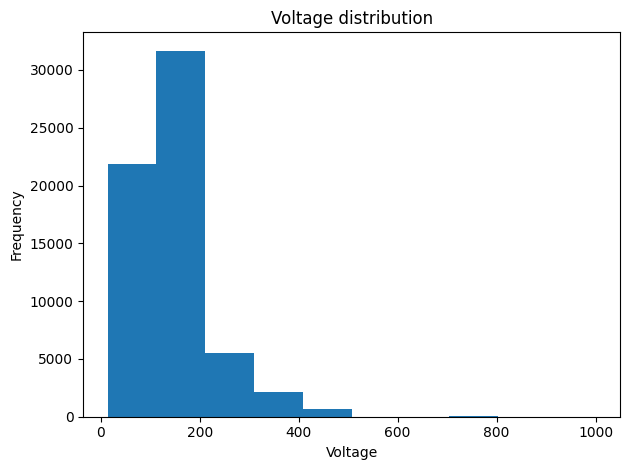

In [67]:
plt.hist(
    x = df_valid["voltage"]
)
plt.xlabel("Voltage")
plt.ylabel("Frequency")
plt.title("Voltage distribution")
plt.tight_layout()
plt.savefig("../results/voltage_distribution.png", bbox_inches = "tight")

## Shape length distribution

In [68]:
df_valid["shape_length"].describe()

count    6.180100e+04
mean     1.456748e+04
std      2.712681e+04
min      2.939312e+00
25%      2.030250e+03
50%      6.961201e+03
75%      1.700704e+04
max      1.781470e+06
Name: shape_length, dtype: float64

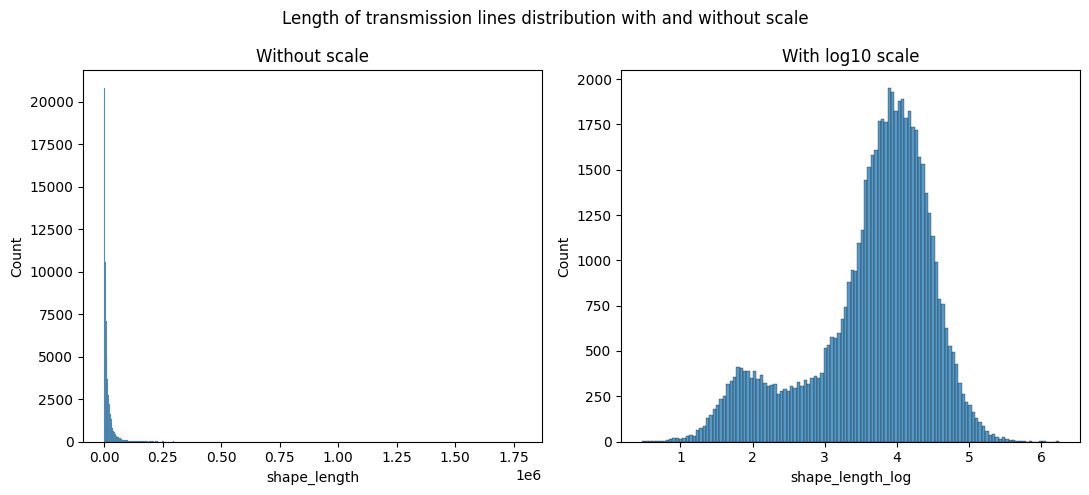

In [69]:
# apply log_10 scale to remove skewness
df_valid["shape_length_log"] = np.log10(df_valid["shape_length"])

fig, ax = plt.subplots(1, 2, figsize = (11, 5))

sns.histplot(
    data = df_valid, 
    x = "shape_length", 
    ax = ax[0]
)

sns.histplot(
    data = df_valid, 
    x = "shape_length_log",
    ax = ax[1]
)

ax[0].set_title("Without scale")
ax[1].set_title("With log10 scale")

plt.suptitle("Length of transmission lines distribution with and without scale")
plt.tight_layout()
plt.savefig("../results/lines_length_distribution.png", bbox_inches = "tight")

## Geographic distribution of transmission line

In [70]:
gdf_valid = gpd.GeoDataFrame(
    df_valid,
    geometry = gpd.points_from_xy(df_valid["longitude"], df_valid["latitude"]),
    crs = "EPSG:4326"
)
gdf_valid.head()

,longitude,latitude,global_id,id,shape_length,status,voltage,shape_length_log,geometry
0,-73.120111,44.712170,b65a6c79-3b92-4d30-9248-02d9b2409ab4,166160,142.530692,In Service,34.5,2.153908,POINT (-73.12011 44.71217)
1,-116.900179,34.860534,275514f9-b987-4557-91f5-0d1af92854ae,313589,16678.594851,In Service,33.0,4.222159,POINT (-116.90018 34.86053)
2,-100.021908,32.248666,653c1c7c-f02d-45ea-ad54-bb339a25eca5,303603,24915.130357,In Service,138.0,4.396463,POINT (-100.02191 32.24867)
3,-94.307355,30.326288,8373aaad-be78-429b-b8e9-3b6e04218328,309745,12273.548069,In Service,138.0,4.088970,POINT (-94.30736 30.32629)
4,-95.664760,29.936748,d3606729-b1ea-421a-9e61-5152cf79cec4,302069,4672.990504,In Service,138.0,3.669595,POINT (-95.66476 29.93675)


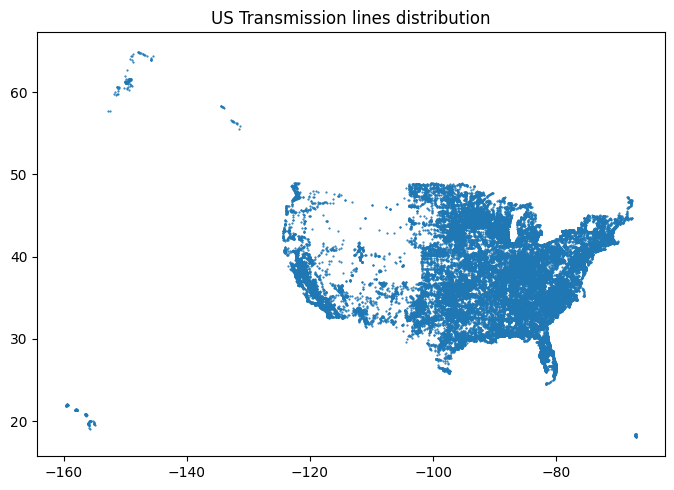

In [71]:
# distribution of all transmission lines in the US

gdf_valid.plot(markersize = 0.3, figsize = (9, 5))
plt.title("US Transmission lines distribution")
plt.tight_layout()
plt.savefig("../results/transmission_lines_map.png", bbox_inches = "tight")

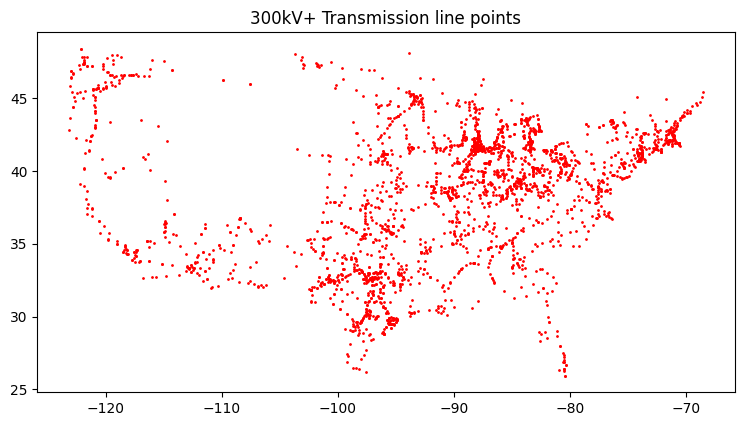

In [72]:
# distribution of high-voltage transmission lines (300kV+)

high_voltage = df[df["voltage"] >= 300]
high_voltage_gdf = gpd.GeoDataFrame(
    high_voltage,
    geometry = gpd.points_from_xy(high_voltage["longitude"], high_voltage["latitude"]),
    crs="EPSG:4326"
)

high_voltage_gdf.plot(figsize = (9, 5.5), markersize=1, color="red")
plt.title("300kV+ Transmission line points")
plt.savefig("../results/high_voltage_map.png", bbox_inches = "tight")

# 4. Spatial join with counties

In [73]:
df_county = gpd.read_file("../raw_data/county_boundaries_2025/tl_2025_us_county.shp")
df_county = df_county.drop(columns = ["COUNTYNS", "GEOIDFQ", "NAME", "LSAD", "CLASSFP", "MTFCC", "CSAFP", "CBSAFP", 
                                      "METDIVFP", "FUNCSTAT", "ALAND", "AWATER", "INTPTLAT", "INTPTLON"])
df_county.columns = ["state_fip_code", "county_fip_code", "geo_id", "county_name", "geometry"]
print(df_county.shape)
df_county.head()

(3235, 5)


,state_fip_code,county_fip_code,geo_id,county_name,geometry
0,40,075,40075,Kiowa County,"POLYGON ((-98.95506 35.11643, -98.94903 35.116..."
1,46,079,46079,Lake County,"POLYGON ((-96.88886 43.9353, -96.88886 43.9351..."
2,37,033,37033,Caswell County,"POLYGON ((-79.14343 36.4422, -79.14345 36.4418..."
3,48,377,48377,Presidio County,"POLYGON ((-104.98078 30.62552, -104.98073 30.6..."
4,39,057,39057,Greene County,"POLYGON ((-84.10668 39.68891, -84.10662 39.689..."


In [74]:
df_join = gpd.sjoin(gdf_valid, df_county.to_crs(gdf_valid.crs), how = "left", predicate = "within")
basic_analysis(df_join)
df_join.head()

(61801, 14)
Index(['longitude', 'latitude', 'global_id', 'id', 'shape_length', 'status',
       'voltage', 'shape_length_log', 'geometry', 'index_right',
       'state_fip_code', 'county_fip_code', 'geo_id', 'county_name'],
      dtype='object')
longitude            0
latitude             0
global_id            0
id                   0
shape_length         0
status               0
voltage              0
shape_length_log     0
geometry             0
index_right         10
state_fip_code      10
county_fip_code     10
geo_id              10
county_name         10
dtype: int64


,longitude,latitude,global_id,id,shape_length,status,voltage,shape_length_log,geometry,index_right,state_fip_code,county_fip_code,geo_id,county_name
0,-73.120111,44.712170,b65a6c79-3b92-4d30-9248-02d9b2409ab4,166160,142.530692,In Service,34.5,2.153908,POINT (-73.12011 44.71217),370.0,50,011,50011,Franklin County
1,-116.900179,34.860534,275514f9-b987-4557-91f5-0d1af92854ae,313589,16678.594851,In Service,33.0,4.222159,POINT (-116.90018 34.86053),817.0,06,071,06071,San Bernardino County
2,-100.021908,32.248666,653c1c7c-f02d-45ea-ad54-bb339a25eca5,303603,24915.130357,In Service,138.0,4.396463,POINT (-100.02191 32.24867),1135.0,48,441,48441,Taylor County
3,-94.307355,30.326288,8373aaad-be78-429b-b8e9-3b6e04218328,309745,12273.548069,In Service,138.0,4.088970,POINT (-94.30736 30.32629),1957.0,48,199,48199,Hardin County
4,-95.664760,29.936748,d3606729-b1ea-421a-9e61-5152cf79cec4,302069,4672.990504,In Service,138.0,3.669595,POINT (-95.66476 29.93675),1574.0,48,201,48201,Harris County


## Counties with the most transmission lines

In [75]:
lines_per_county = df_join[["county_name", "geo_id", "id"]].groupby(["county_name", "geo_id"]).agg("count").reset_index()
lines_per_county.columns = ["county_name", "geo_id", "number_of_lines"]
lines_per_county

,county_name,geo_id,number_of_lines
0,Abbeville County,45001,11
1,Acadia Parish,22001,28
2,Accomack County,51001,23
3,Adair County,19001,3
4,Adair County,21001,7
...,...,...,...
2860,Yukon-Koyukuk Census Area,02290,3
2861,Yuma County,04027,28
2862,Zapata County,48505,1
2863,Zavala County,48507,2


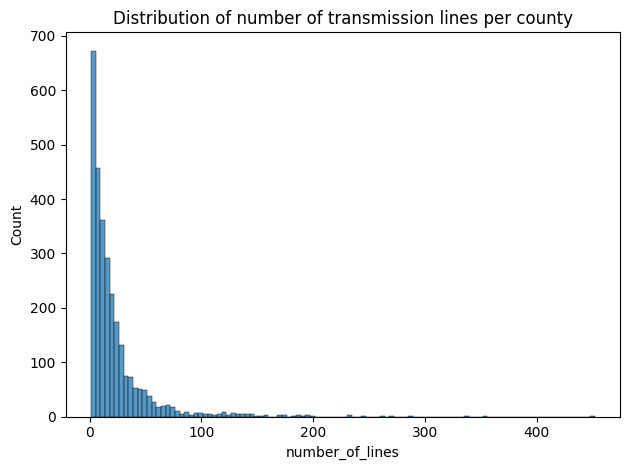

In [76]:
sns.histplot(
    data = lines_per_county,
    x = "number_of_lines"
)
plt.title("Distribution of number of transmission lines per county")
plt.tight_layout()
plt.savefig("../results/transmission_lines_distribution.png", bbox_inches = "tight")

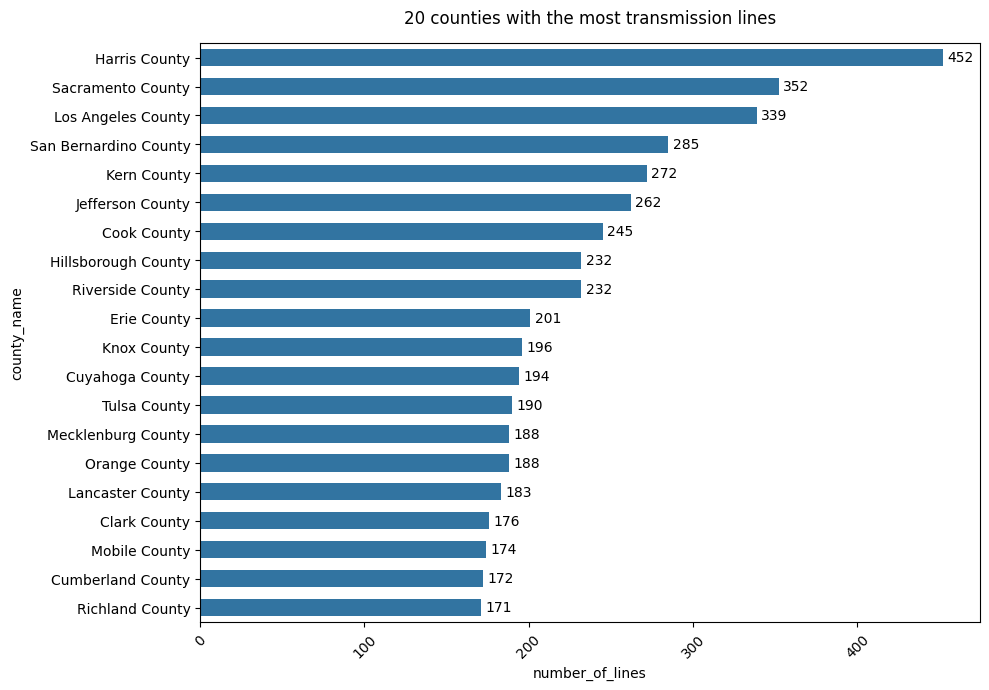

In [77]:
plt.figure(figsize = (10, 7))
ax = sns.barplot(
    data = lines_per_county.nlargest(20, "number_of_lines"),
    y = "county_name",
    x = "number_of_lines",
    width = 0.6
)
for container in ax.containers:
  ax.bar_label(container, padding = 3)
plt.xticks(rotation = 45)
plt.title("20 counties with the most transmission lines", y = 1.02)
plt.tight_layout()
plt.savefig("../results/counties_most_lines.png", bbox_inches = "tight")

In [78]:
df_county

,state_fip_code,county_fip_code,geo_id,county_name,geometry
0,40,075,40075,Kiowa County,"POLYGON ((-98.95506 35.11643, -98.94903 35.116..."
1,46,079,46079,Lake County,"POLYGON ((-96.88886 43.9353, -96.88886 43.9351..."
2,37,033,37033,Caswell County,"POLYGON ((-79.14343 36.4422, -79.14345 36.4418..."
3,48,377,48377,Presidio County,"POLYGON ((-104.98078 30.62552, -104.98073 30.6..."
4,39,057,39057,Greene County,"POLYGON ((-84.10668 39.68891, -84.10662 39.689..."
...,...,...,...,...,...
3230,53,065,53065,Stevens County,"POLYGON ((-117.86678 47.84506, -117.8669 47.84..."
3231,19,177,19177,Van Buren County,"POLYGON ((-92.17907 40.89972, -92.17704 40.899..."
3232,31,073,31073,Gosper County,"POLYGON ((-99.98139 40.62501, -99.9814 40.6269..."
3233,28,095,28095,Monroe County,"POLYGON ((-88.22909 33.89194, -88.2291 33.8918..."


In [80]:
df_lines = df_join.groupby(["geo_id", "county_name"]).agg(
    total_voltage = ("voltage", "sum"),
    max_voltage = ("voltage", "max"),
    lines_count = ("id", "count")
).reset_index()
df_lines

,geo_id,county_name,total_voltage,max_voltage,lines_count
0,01001,Autauga County,5105.0,500.0,27
1,01003,Baldwin County,12575.0,500.0,99
2,01005,Barbour County,1995.0,500.0,14
3,01007,Bibb County,1305.0,500.0,7
4,01009,Blount County,3651.0,500.0,26
...,...,...,...,...,...
2860,72011,Añasco Municipio,115.0,115.0,1
2861,72071,Isabela Municipio,230.0,230.0,1
2862,72097,Mayagüez Municipio,689.0,115.0,8
2863,72099,Moca Municipio,153.0,115.0,2


In [82]:
gdf_valid

,longitude,latitude,global_id,id,shape_length,status,voltage,shape_length_log,geometry
0,-73.120111,44.712170,b65a6c79-3b92-4d30-9248-02d9b2409ab4,166160,142.530692,In Service,34.5,2.153908,POINT (-73.12011 44.71217)
1,-116.900179,34.860534,275514f9-b987-4557-91f5-0d1af92854ae,313589,16678.594851,In Service,33.0,4.222159,POINT (-116.90018 34.86053)
2,-100.021908,32.248666,653c1c7c-f02d-45ea-ad54-bb339a25eca5,303603,24915.130357,In Service,138.0,4.396463,POINT (-100.02191 32.24867)
3,-94.307355,30.326288,8373aaad-be78-429b-b8e9-3b6e04218328,309745,12273.548069,In Service,138.0,4.088970,POINT (-94.30736 30.32629)
4,-95.664760,29.936748,d3606729-b1ea-421a-9e61-5152cf79cec4,302069,4672.990504,In Service,138.0,3.669595,POINT (-95.66476 29.93675)
...,...,...,...,...,...,...,...,...,...
61796,-89.949726,35.182783,ceada46a-ce8a-430a-81e7-9e575e31f592,140653,8418.231164,In Service,161.0,3.925221,POINT (-89.94973 35.18278)
61797,-80.671768,36.174691,2944102d-db5a-4f7a-9a61-17cd0906bd8e,115425,10641.961585,In Service,100.0,4.027022,POINT (-80.67177 36.17469)
61798,-101.558691,35.645363,0d9dd087-2d20-4329-b7f3-279f114250c1,308939,37.065286,In Service,115.0,1.568967,POINT (-101.55869 35.64536)
61799,-84.084103,37.148136,ee609a3e-11f5-4f39-ab23-d7b18a480c62,100997,4191.577383,In Service,69.0,3.622377,POINT (-84.0841 37.14814)


In [ ]:
lines_combined = gdf_valid.geometry.union_all()
df_lines["dist_to_lakes_km"] = df_county["centroid"].apply(
    lambda x: x.distance(lakes_combined) / 1000
)